In [131]:
# --- CELL 1: IMPORTS ---
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from collections import deque
import sys
import time

# --- New Imports for Polishing and 3D Visualization ---
from scipy.optimize import minimize, Bounds, LinearConstraint
import plotly.graph_objects as go
from sklearn.decomposition import PCA


In [133]:
# --- CELL 2: HYBRID POWER FLOW OPTIMIZER CLASS ---
# This class performs the metaheuristic global search to find a high-quality 
# solution region. It includes data logging for analysis and is the first
# stage of the two-part "Hybrid Polish" optimization process.

class HybridPowerFlowOptimizer:
    """
    Optimizes power flow using a hybrid metaheuristic approach, incorporating
    local search, adaptive algorithm selection, stagnation handling, and
    adaptive parameters. Allows zero-cost load shedding.
    """

    def __init__(self, A_matrix, line_limits, gen_costs, gen_limits_min, gen_limits_max, initial_B, memory_size=100):
        """
        Initializes the HybridPowerFlowOptimizer.
        MODIFIED to disable initial clamping of generator limits.
        """
        self.A = A_matrix
        self.line_limits = np.array(line_limits, dtype=np.float64)
        self.num_lines = A_matrix.shape[0]
        self.num_buses = A_matrix.shape[1]
        self.tolerance = 1e-6

        self.initial_B = initial_B.copy().flatten()

        self.gen_indices = np.where(self.initial_B > self.tolerance)[0]
        self.load_indices = np.where(self.initial_B <= self.tolerance)[0]

        if len(self.gen_indices) == 0:
            raise ValueError("No generator buses identified (initial B > 0). Cannot proceed.")

        print(f"Identified {len(self.gen_indices)} generator buses (indices: {self.gen_indices})")
        print(f"Identified {len(self.load_indices)} load buses (indices: {self.load_indices}) - Load shedding enabled (but penalized).")

        flat_gc = np.array(gen_costs).flatten()
        flat_gmin = np.array(gen_limits_min).flatten()
        flat_gmax = np.array(gen_limits_max).flatten()
        if len(flat_gc) != self.num_buses or len(flat_gmin) != self.num_buses or len(flat_gmax) != self.num_buses:
            raise ValueError(f"Generator cost/limit array length mismatch (Expected {self.num_buses})")
        self.gen_costs_only = flat_gc[self.gen_indices]
        self.gen_limits_min_only = flat_gmin[self.gen_indices]
        self.gen_limits_max_only = flat_gmax[self.gen_indices]
        if np.any(self.gen_limits_max_only < self.gen_limits_min_only):
            raise ValueError("Generator Max limit cannot be less than Min limit.")

        self.initial_B_load_fixed = self.initial_B[self.load_indices]
        self.load_limits_min_only = self.initial_B_load_fixed
        self.load_limits_max_only = np.zeros_like(self.load_limits_min_only)

        # The initial clamping of generator values has been disabled.
        
        # Power balancing logic
        needs_adjust = False
        required_total_injection = 0.0
        current_total_injection = np.sum(self.initial_B)
        difference_init = required_total_injection - current_total_injection
        num_gens = len(self.gen_indices)

        if abs(difference_init) > self.tolerance * self.num_buses:
            print(f"Warning: Initial injections sum to {current_total_injection:.4f} (≠ 0). Adjusting generators to balance...")
            if num_gens > 0:
                diff_per_gen_init = difference_init / num_gens
                adjusted_gens = self.initial_B[self.gen_indices] + diff_per_gen_init
                clipped_adjusted_gens = np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only)
                actual_adjustment_applied = np.sum(clipped_adjusted_gens) - np.sum(self.initial_B[self.gen_indices])
                self.initial_B[self.gen_indices] = clipped_adjusted_gens
                remaining_diff = difference_init - actual_adjustment_applied
                if abs(remaining_diff) > self.tolerance * self.num_buses:
                    print(f"Warning: Could not fully balance initial state due to gen limits. Remaining imbalance: {remaining_diff:.4f}")
                needs_adjust = True
            else:
                print("ERROR: Cannot balance initial state - no generators identified.")
                needs_adjust = True

        if needs_adjust:
            print("-> Adjusted initial B state used for optimization:", np.round(self.initial_B, 4))

        self.memory = deque(maxlen=memory_size)
        self.stagnation_threshold = 50
        self.diversification_fraction = 0.2

    def _apply_constraints(self, solution_vector):
        sol = solution_vector.copy().flatten()
        num_gens = len(self.gen_indices)
        num_loads = len(self.load_indices)

        if num_loads > 0:
            sol[self.load_indices] = np.clip(sol[self.load_indices], self.load_limits_min_only, self.load_limits_max_only)

        if num_gens > 0:
            sol[self.gen_indices] = np.clip(sol[self.gen_indices], self.gen_limits_min_only, self.gen_limits_max_only)

        if num_gens > 0:
            current_load_sum = np.sum(sol[self.load_indices]) if num_loads > 0 else 0.0
            required_gen_sum = -current_load_sum
            current_gen_sum = np.sum(sol[self.gen_indices])
            difference = required_gen_sum - current_gen_sum

            if abs(difference) > self.tolerance * self.num_buses:
                adjustment_per_gen = difference / num_gens
                adjusted_gens = sol[self.gen_indices] + adjustment_per_gen
                clipped_adjusted_gens = np.clip(adjusted_gens, self.gen_limits_min_only, self.gen_limits_max_only)
                sol[self.gen_indices] = clipped_adjusted_gens

        return sol.reshape(-1, 1)

    def _calculate_fitness(self, solution):
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)): return np.inf

        try:
            C = np.dot(self.A, sol_flat)
            if not np.all(np.isfinite(C)): return np.inf
            flows = C.flatten()
        except ValueError:
            return np.inf

        penalty_multiplier = 1e10
        line_violations = np.maximum(0, np.abs(flows) - (self.line_limits + self.tolerance))
        line_violation_penalty = penalty_multiplier * np.sum(line_violations**2)

        gen_limit_penalty = 0.0
        if len(self.gen_indices) > 0:
            gen_values = sol_flat[self.gen_indices]
            violations_lower_g = np.maximum(0, self.gen_limits_min_only - gen_values + self.tolerance)
            violations_upper_g = np.maximum(0, gen_values - self.gen_limits_max_only - self.tolerance)
            gen_limit_penalty = penalty_multiplier * (np.sum(violations_lower_g**2) + np.sum(violations_upper_g**2))

        load_limit_penalty = 0.0
        if len(self.load_indices) > 0:
            load_values = sol_flat[self.load_indices]
            violations_lower_l = np.maximum(0, self.load_limits_min_only - load_values + self.tolerance)
            violations_upper_l = np.maximum(0, load_values - self.load_limits_max_only - self.tolerance)
            load_limit_penalty = penalty_multiplier * (np.sum(violations_lower_l**2) + np.sum(violations_upper_l**2))

        balance_violation = abs(np.sum(sol_flat))
        balance_penalty = penalty_multiplier * (balance_violation**2) if balance_violation > self.tolerance * self.num_buses else 0.0

        generator_deviation = self._get_generator_deviation(solution)
        deviation_penalty_component = 1e5 * generator_deviation
        gen_rescheduling_cost = self._get_rescheduling_cost(solution)
        gen_cost_weight = 0.1

        # --- NEW: PENALTY FOR LOAD SHEDDING ---
        # This component directly penalizes the amount of load shed.
        load_shed_penalty = 0.0
        if len(self.load_indices) > 0:
            # Load shed is the positive difference between the current (less negative) load
            # and the initial (more negative) load.
            initial_loads = self.initial_B[self.load_indices]
            current_loads = sol_flat[self.load_indices]
            total_load_shed = np.sum(np.maximum(0, current_loads - initial_loads))
            
            # A heavy weight to make load shedding highly undesirable
            load_shed_penalty_weight = 1e6 
            load_shed_penalty = load_shed_penalty_weight * total_load_shed

        # --- UPDATED: Total fitness now includes the load shed penalty ---
        fitness = (line_violation_penalty + 
                   gen_limit_penalty + 
                   load_limit_penalty + 
                   balance_penalty +
                   deviation_penalty_component + 
                   gen_cost_weight * gen_rescheduling_cost +
                   load_shed_penalty) # Added penalty
                   
        return fitness if np.isfinite(fitness) else np.inf

    def _is_feasible(self, solution, verbose=False):
        if solution is None:
            if verbose: print("DEBUG (_is_feasible): Input solution is None.")
            return False
        sol_flat = solution.flatten()
        if not np.all(np.isfinite(sol_flat)):
            if verbose: print("DEBUG (_is_feasible): Solution contains non-finite values.")
            return False

        try:
            flows = np.dot(self.A, sol_flat).flatten()
            line_ok = np.all(np.abs(flows) <= self.line_limits + self.tolerance)
        except Exception as e:
            line_ok = False
            if verbose: print(f"DEBUG: Line check error: {e}")

        gen_values = sol_flat[self.gen_indices] if len(self.gen_indices) > 0 else np.array([])
        gen_ok = (len(self.gen_indices) == 0 or
                  (len(gen_values) == len(self.gen_limits_min_only) and
                   np.all(gen_values >= self.gen_limits_min_only - self.tolerance) and
                   np.all(gen_values <= self.gen_limits_max_only + self.tolerance)))

        load_values = sol_flat[self.load_indices] if len(self.load_indices) > 0 else np.array([])
        load_ok = (len(self.load_indices) == 0 or
                   (len(load_values) == len(self.load_limits_min_only) and
                    np.all(load_values >= self.load_limits_min_only - self.tolerance) and
                    np.all(load_values <= self.load_limits_max_only + self.tolerance)))

        bal_ok = abs(np.sum(sol_flat)) < self.tolerance * self.num_buses
        feasible = line_ok and gen_ok and load_ok and bal_ok

        if verbose or not feasible:
            print(f"--- Feasibility Check {'FAILED' if not feasible else 'PASSED'} ---")
            if not line_ok:
                failing_lines = np.where(np.abs(flows) > self.line_limits + self.tolerance)[0]
                print(f"  Line constraints failed. Failing lines: {failing_lines+1}")
            else: print("  Line constraints met.")
            if not gen_ok: print("  Generator limits failed.")
            else: print("  Generator limits met.")
            if not load_ok: print("  Load limits failed.")
            else: print("  Load limits met.")
            if not bal_ok: print(f"  Power balance check failed, sum={np.sum(sol_flat):.8f}")
            else: print("  Power balance met.")
            print("-" * 40)
        return feasible

    def _get_generator_deviation(self, solution):
        sol_flat = solution.flatten()
        if len(self.gen_indices) == 0: return 0.0
        return np.sum(np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices]))

    def _get_rescheduling_cost(self, solution):
        sol_flat = solution.flatten()
        if len(self.gen_indices) == 0: return 0.0
        deviation = np.abs(sol_flat[self.gen_indices] - self.initial_B[self.gen_indices])
        return np.sum(self.gen_costs_only * deviation)

    def _generate_random_solution(self):
        rand_sol = self.initial_B.copy()
        n_gens = len(self.gen_indices)
        if n_gens > 0:
            gen_range = np.maximum(self.tolerance, self.gen_limits_max_only - self.gen_limits_min_only)
            perturbations = (np.random.rand(n_gens) - 0.5) * gen_range * 0.2
            rand_sol[self.gen_indices] = np.clip(self.initial_B[self.gen_indices] + perturbations,
                                                  self.gen_limits_min_only, self.gen_limits_max_only)
        n_loads = len(self.load_indices)
        if n_loads > 0:
            potential_increase = np.random.rand(n_loads) * np.abs(self.initial_B[self.load_indices]) * 0.1
            rand_sol[self.load_indices] = np.clip(self.initial_B[self.load_indices] + potential_increase,
                                                   self.load_limits_min_only, self.load_limits_max_only)
        return self._apply_constraints(rand_sol)

    def _apply_local_search(self, solution, iteration, max_iterations):
        current_solution = solution.copy()
        current_fitness = self._calculate_fitness(current_solution)
        if not np.isfinite(current_fitness): return solution

        progress_ratio = iteration / max_iterations
        step_scale_factor = 0.1 * (1.0 - progress_ratio) + 0.01 * progress_ratio
        num_attempts = min(5, int(np.sqrt(self.num_buses)))

        for _ in range(num_attempts):
            idx_to_perturb = random.randrange(self.num_buses)
            perturbed_solution = current_solution.copy()
            perturb_range = 1.0
            if idx_to_perturb in self.gen_indices:
                gen_idx_local = np.where(self.gen_indices == idx_to_perturb)[0][0]
                gen_op_range = self.gen_limits_max_only[gen_idx_local] - self.gen_limits_min_only[gen_idx_local]
                perturb_range = max(self.tolerance, gen_op_range) * step_scale_factor
            elif idx_to_perturb in self.load_indices:
                load_idx_local = np.where(self.load_indices == idx_to_perturb)[0][0]
                load_op_range = self.load_limits_max_only[load_idx_local] - self.load_limits_min_only[load_idx_local]
                perturb_range = max(self.tolerance, load_op_range) * step_scale_factor

            perturbation = (random.random() - 0.5) * 2 * perturb_range
            perturbed_solution[idx_to_perturb, 0] += perturbation
            refined_solution = self._apply_constraints(perturbed_solution)
            refined_fitness = self._calculate_fitness(refined_solution)

            if np.isfinite(refined_fitness) and refined_fitness < current_fitness:
                current_solution = refined_solution
                current_fitness = refined_fitness
        return current_solution

    def optimize(self, B_unused, iterations=200, population_size=30, log_filename=None):
        print(f"Starting Metaheuristic Search: Pop={population_size}, Iterations={iterations}")
        if log_filename:
            print(f"Logging iteration data to: {log_filename}")

        log_file, csv_writer = None, None
        if log_filename:
            try:
                header = ["Iteration", "Best_Fitness", "Stagnation_Counter", "Total_Load_Shed",
                          "Gen_Deviation_Sum", "Gen_Rescheduling_Cost", "Num_Line_Violations",
                          "Max_Line_Violation_Pct", "Prob_OOA", "Prob_KHA", "Prob_SHO"] + \
                         [f"B_{i+1}" for i in range(self.num_buses)]
                log_file = open(log_filename, 'w', newline='')
                csv_writer = csv.writer(log_file)
                csv_writer.writerow(header)
            except IOError as e:
                print(f"Warning: Could not open log file '{log_filename}'. Logging disabled. Error: {e}")
                log_file, csv_writer = None, None

        initial_population = [self._generate_random_solution() for _ in range(population_size)]
        initial_population[0] = self._apply_constraints(self.initial_B)
        fitness_values = [self._calculate_fitness(sol) for sol in initial_population]
        best_idx = np.argmin(fitness_values)
        best_solution = initial_population[best_idx].copy()
        best_fitness = fitness_values[best_idx]

        if not np.isfinite(best_fitness):
            print("ERROR: Initial best fitness is non-finite. Trying to recover...")
            finite_indices = np.where(np.isfinite(fitness_values))[0]
            if len(finite_indices) > 0:
                best_idx = finite_indices[np.argmin(np.array(fitness_values)[finite_indices])]
                best_solution = initial_population[best_idx].copy()
                best_fitness = fitness_values[best_idx]
            else:
                print("FATAL: No finite solutions found. Returning initial state.")
                return self.initial_B.reshape(-1, 1), [], np.dot(self.A, self.initial_B)

        print(f"Initial Best Fitness: {best_fitness:.4e}")
        fitness_history = [best_fitness]
        algorithm_names = ['OOA', 'KHA', 'SHO']
        algo_success_count = {name: 0 for name in algorithm_names}
        algo_attempts_count = {name: 0 for name in algorithm_names}
        algo_probabilities = {name: 1.0 / len(algorithm_names) for name in algorithm_names}
        adaptation_rate, stagnation_counter, last_best_fitness = 0.05, 0, best_fitness

        try:
            for iteration in range(iterations):
                total_attempts = sum(algo_attempts_count.values())
                if total_attempts > 0:
                    success_rates = {name: algo_success_count[name] / algo_attempts_count[name] if algo_attempts_count[name] > 0 else 0 for name in algorithm_names}
                    total_rate = sum(success_rates.values())
                    if total_rate > 1e-6:
                        target_probabilities = {name: rate / total_rate for name, rate in success_rates.items()}
                        for name in algorithm_names:
                            algo_probabilities[name] = (1 - adaptation_rate) * algo_probabilities[name] + adaptation_rate * target_probabilities[name]
                        prob_sum = sum(algo_probabilities.values())
                        if prob_sum > 1e-6:
                            algo_probabilities = {name: p / prob_sum for name, p in algo_probabilities.items()}
                        else:
                            algo_probabilities = {name: 1.0/len(algorithm_names) for name in algorithm_names}

                current_weights = list(algo_probabilities.values())
                if not (len(current_weights) == len(algorithm_names) and abs(sum(current_weights) - 1.0) < 1e-5 and all(w >= 0 for w in current_weights)):
                    current_weights = [1.0/len(algorithm_names)] * len(algorithm_names)
                
                new_population = list(initial_population)
                new_fitness_values = list(fitness_values)

                for i in range(population_size):
                    algorithm = random.choices(algorithm_names, weights=current_weights, k=1)[0]
                    algo_attempts_count[algorithm] += 1
                    
                    if algorithm == 'OOA': candidate_solution = self._apply_orcas_optimization(initial_population, i, best_solution, iteration, iterations)
                    elif algorithm == 'KHA': candidate_solution = self._apply_krill_herd(initial_population, i, best_solution, iteration, iterations)
                    else: candidate_solution = self._apply_spotted_hyena(initial_population, i, best_solution, iteration, iterations)
                    
                    refined_candidate = self._apply_local_search(candidate_solution, iteration, iterations)
                    new_solution = self._apply_constraints(refined_candidate)
                    new_fitness = self._calculate_fitness(new_solution)

                    if new_fitness < new_fitness_values[i]:
                        new_population[i] = new_solution
                        new_fitness_values[i] = new_fitness

                    if new_fitness < best_fitness:
                        best_fitness = new_fitness
                        best_solution = new_solution.copy()
                        algo_success_count[algorithm] += 1
                
                initial_population = new_population
                fitness_values = new_fitness_values

                if abs(best_fitness - last_best_fitness) < self.tolerance * max(1.0, abs(last_best_fitness)):
                    stagnation_counter += 1
                else:
                    stagnation_counter, last_best_fitness = 0, best_fitness
                
                if stagnation_counter >= self.stagnation_threshold:
                    print(f"\nStagnation detected at iteration {iteration}. Diversifying population...")
                    num_to_replace = int(population_size * self.diversification_fraction)
                    worst_indices = np.argsort(fitness_values)[-num_to_replace:]
                    for idx in worst_indices:
                        initial_population[idx] = self._generate_random_solution()
                        fitness_values[idx] = self._calculate_fitness(initial_population[idx])
                    
                    current_best_idx_after_diversify = np.argmin(fitness_values)
                    if fitness_values[current_best_idx_after_diversify] < best_fitness:
                        best_solution = initial_population[current_best_idx_after_diversify].copy()
                        best_fitness = fitness_values[current_best_idx_after_diversify]
                    
                    last_best_fitness = best_fitness
                    stagnation_counter = 0

                if csv_writer:
                    best_sol_flat = best_solution.flatten()
                    flows = np.dot(self.A, best_sol_flat).flatten()
                    line_violations = np.maximum(0, np.abs(flows) - (self.line_limits + self.tolerance))
                    num_line_violations = np.sum(line_violations > 0)
                    safe_limits = np.where(self.line_limits > self.tolerance, self.line_limits, self.tolerance)
                    max_line_violation_pct = np.max(line_violations / safe_limits) * 100 if num_line_violations > 0 else 0.0
                    gen_dev, gen_cost = self._get_generator_deviation(best_solution), self._get_rescheduling_cost(best_solution)
                    load_shed_amount = np.sum(np.maximum(0, best_sol_flat[self.load_indices] - self.initial_B[self.load_indices])) if len(self.load_indices) > 0 else 0.0
                    
                    log_row = [iteration, best_fitness, stagnation_counter, load_shed_amount, gen_dev, gen_cost,
                               num_line_violations, max_line_violation_pct] + list(algo_probabilities.values()) + best_sol_flat.tolist()
                    csv_writer.writerow(log_row)

                if iteration % 100 == 0 or iteration == iterations - 1:
                    deviation = self._get_generator_deviation(best_solution)
                    cost = self._get_rescheduling_cost(best_solution)
                    print(f"Iter {iteration}/{iterations}: BestFit={best_fitness:.4e}, Deviation={deviation:.3f}, GenCost={cost:.2f}")
                
                fitness_history.append(best_fitness)
        finally:
            if log_file:
                log_file.close()
                print(f"Finished logging iteration data to {log_filename}.")

        final_C = np.dot(self.A, self._apply_constraints(best_solution))
        return self._apply_constraints(best_solution), fitness_history, final_C
    
    def _apply_orcas_optimization(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()
        a = 2 * (1 - (iteration / max_iterations)**2)
        r1, r2 = random.random(), random.random()
        if r1 < 0.5:
            step = a * r2 * (best_sol_flat - sol_flat)
            new_solution_flat = sol_flat + step
        else:
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_solution_idx = random.choice(other_indices) if other_indices else current_index
            random_solution = population[random_solution_idx].flatten()
            A_param = 2 * a * r1 - a
            C_param = 2 * r2
            D_param = np.abs(C_param * random_solution - sol_flat)
            new_solution_flat = random_solution - A_param * D_param
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat))
        return new_solution_flat.reshape(-1, 1)

    def _apply_krill_herd(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()
        Dmax = 0.005 * (1 - iteration / max_iterations)
        Vf, Nmax, Dt = 0.02, 0.01, 1.0
        N_induced = Nmax * (best_sol_flat - sol_flat)
        F_foraging = Vf * (best_sol_flat - sol_flat)
        diffusion_vector = np.random.uniform(-1, 1, sol_flat.shape)
        D_physical = Dmax * diffusion_vector
        new_solution_flat = sol_flat + Dt * (N_induced + F_foraging + D_physical)
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat))
        return new_solution_flat.reshape(-1, 1)

    def _apply_spotted_hyena(self, population, current_index, best_solution_global, iteration, max_iterations):
        solution = population[current_index].copy()
        best_sol_flat = best_solution_global.flatten()
        sol_flat = solution.flatten()
        h = 5 - iteration * (5 / max_iterations)
        B_param = 2 * random.random()
        E_param = 2 * h * random.random() - h
        D_best = np.abs(B_param * best_sol_flat - sol_flat)
        X1 = best_sol_flat - E_param * D_best
        if abs(E_param) >= 1:
            other_indices = [j for j in range(len(population)) if j != current_index]
            random_hyena_idx = random.choice(other_indices) if other_indices else current_index
            random_hyena = population[random_hyena_idx].flatten()
            D_hyena = np.abs(B_param * random_hyena - sol_flat)
            new_solution_flat = random_hyena - E_param * D_hyena
        else:
            new_solution_flat = X1
        new_solution_flat = np.nan_to_num(new_solution_flat, nan=np.mean(sol_flat))
        return new_solution_flat.reshape(-1, 1)


In [135]:
# --- CELL 3: WRAPPER FUNCTION (MODIFIED FOR HYBRID POLISH) ---

def optimize_power_flow_hybrid_polish(A, B, line_limits, gen_costs, gen_limits_min, gen_limits_max,
                                      iterations=2000, population_size=50): # log_filename removed
    """
    Performs a two-stage hybrid optimization without iteration logging.
    """
    # --- STAGE 1: METAHEURISTIC GLOBAL SEARCH ---
    print("--- STAGE 1: Starting Metaheuristic Global Search ---")
    optimizer = HybridPowerFlowOptimizer(A, line_limits, gen_costs, gen_limits_min, gen_limits_max, B)
    
    # Call optimizer without the log_filename argument
    B_meta, fit_hist, _ = optimizer.optimize(
        None,
        iterations=iterations,
        population_size=population_size
    )

    print("\n--- Metaheuristic Search Complete ---")
    print(f"Best solution from Stage 1: (Deviation: {optimizer._get_generator_deviation(B_meta):.4f})")

    # --- STAGE 2: GRADIENT-BASED LOCAL POLISH ---
    print("\n--- STAGE 2: Starting Gradient-Based 'Polish' ---")
    x0 = B_meta.flatten()

    def objective_function(b_vector):
        gen_dev = np.sum(np.abs(b_vector[optimizer.gen_indices] - optimizer.initial_B[optimizer.gen_indices]))
        initial_loads = optimizer.initial_B[optimizer.load_indices]
        current_loads = b_vector[optimizer.load_indices]
        total_load_shed = np.sum(np.maximum(0, current_loads - initial_loads))
        deviation_cost = 1e5 * gen_dev
        load_shed_cost = 1e6 * total_load_shed
        return deviation_cost + load_shed_cost

    b_bounds = np.zeros((optimizer.num_buses, 2))
    b_bounds[optimizer.gen_indices, 0] = optimizer.gen_limits_min_only
    b_bounds[optimizer.gen_indices, 1] = optimizer.gen_limits_max_only
    b_bounds[optimizer.load_indices, 0] = optimizer.load_limits_min_only
    b_bounds[optimizer.load_indices, 1] = optimizer.load_limits_max_only
    bounds = Bounds(b_bounds[:, 0], b_bounds[:, 1])

    constraint_matrix = np.vstack([np.ones((1, optimizer.num_buses)), A, -A])
    lower_bounds_constr = np.hstack([0, -line_limits, -line_limits])
    upper_bounds_constr = np.hstack([0, line_limits, line_limits])
    constraints = LinearConstraint(constraint_matrix, lower_bounds_constr, upper_bounds_constr)

    print("Invoking SciPy SLSQP solver for final precision polish...")
    polish_result = minimize(
        objective_function, x0, method='SLSQP', bounds=bounds,
        constraints=constraints, options={'disp': True, 'ftol': 1e-9, 'maxiter': 500}
    )

    B_polished = polish_result.x.reshape(-1, 1)
    
    print("\n--- Polish Complete ---")
    final_deviation = optimizer._get_generator_deviation(B_polished)
    print(f"Final polished solution deviation: {final_deviation:.6f}")

    C_polished = np.dot(A, B_polished)
    C_unoptimized = np.dot(A, optimizer.initial_B.reshape(-1, 1))
    final_feasible = optimizer._is_feasible(B_polished, verbose=True)
    details = {"gen_indices": optimizer.gen_indices, "load_indices": optimizer.load_indices}

    return B_polished, fit_hist, C_polished, C_unoptimized, final_feasible, details


In [137]:
# --- CELL 4: VISUALIZATION FUNCTIONS ---
# This cell contains all functions for creating the 2D plots, the 3D topological map,
# and for saving the final text-based report.

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import time

def visualize_detailed_results(B_initial, B_optimized, C_unoptimized, C_optimized, line_limits, fitness_history, details):
    """
    Creates detailed 2D plots for comparing results, including a line flow
    comparison graph, a fitness convergence plot, and a load shedding summary.
    """
    print("\n--- Generating Detailed 2D Result Plots ---")
    
    num_lines = len(line_limits)
    tolerance = 1e-6 

    # --- Plot 1: Line Flow Comparison (Bar Graph) ---
    try:
        plt.figure(figsize=(18, 9))
        idx = np.arange(1, num_lines + 1)
        bar_width = 0.4

        # --- Unoptimized flows ---
        unopt_flows_abs = np.abs(C_unoptimized.flatten())
        unopt_violation_mask = unopt_flows_abs > line_limits + tolerance
        unopt_ok_mask = ~unopt_violation_mask
        
        # Plot unoptimized flows that are OK (within limit)
        plt.bar(idx[unopt_ok_mask] - bar_width/2, unopt_flows_abs[unopt_ok_mask], width=bar_width,
                color='skyblue', alpha=0.9, label='Unoptimized (Within Limit)')
        # Plot unoptimized flows that are in violation
        if np.any(unopt_violation_mask):
            plt.bar(idx[unopt_violation_mask] - bar_width/2, unopt_flows_abs[unopt_violation_mask], width=bar_width,
                    color='salmon', alpha=0.9, label='Unoptimized (Violation)')

        # --- Optimized flows ---
        opt_flows_abs = np.abs(C_optimized.flatten())
        opt_violation_mask = opt_flows_abs > line_limits + tolerance
        opt_ok_mask = ~opt_violation_mask

        # Plot optimized flows that are OK (within limit)
        plt.bar(idx[opt_ok_mask] + bar_width/2, opt_flows_abs[opt_ok_mask], width=bar_width,
                color='forestgreen', alpha=0.9, label='Optimized (Within Limit)')
        # Plot optimized flows that are in violation
        if np.any(opt_violation_mask):
             plt.bar(idx[opt_violation_mask] + bar_width/2, opt_flows_abs[opt_violation_mask], width=bar_width,
                     color='crimson', alpha=0.9, label='Optimized (Violation)')

        # Line limits as a dashed line
        plt.plot(idx, line_limits, 'k--', alpha=0.8, linewidth=2, label='Line Limit')

        plt.xlabel('Line Index', fontsize=12)
        plt.ylabel('Absolute Power Flow (MW or p.u.)', fontsize=12)
        plt.title('Side-by-Side Line Flows Comparison', fontsize=16, fontweight='bold')
        plt.xticks(idx[::max(1, num_lines // 25)]) 
        plt.grid(True, axis='y', linestyle=':', alpha=0.7)
        
        # Create a comprehensive custom legend
        import matplotlib.patches as mpatches
        from matplotlib.lines import Line2D
        
        legend_elements = [
            mpatches.Patch(color='skyblue', label='Unoptimized (Within Limit)'),
            mpatches.Patch(color='salmon', label='Unoptimized (Violation)'),
            mpatches.Patch(color='forestgreen', label='Optimized (Within Limit)'),
            mpatches.Patch(color='crimson', label='Optimized (Violation)'),
            Line2D([0], [0], color='k', lw=2, linestyle='--', label='Line Limit')
        ]
        plt.legend(handles=legend_elements, fontsize=11)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error plotting line flow comparison: {e}")

    # --- Plot 2: Fitness Convergence ---
    try:
        if fitness_history and len(fitness_history) > 1:
            plt.figure(figsize=(12, 6))
            finite_fitness = [f for f in fitness_history if np.isfinite(f) and f > 0]
            
            if len(finite_fitness) > 1:
                plt.plot(finite_fitness, '.-', color='royalblue', markersize=4, linewidth=1.5, alpha=0.8)
                plt.xlabel('Iteration', fontsize=12)
                plt.ylabel('Fitness Value (Log Scale)', fontsize=12)
                plt.title('Fitness Convergence of Metaheuristic Search (Stage 1)', fontsize=14, fontweight='bold')
                plt.yscale('log')
                plt.grid(True, which="both", linestyle='--', linewidth=0.5)
                plt.tight_layout()
                plt.show()
            else:
                print("Warning: Not enough valid fitness data to plot convergence.")
        else:
            print("Warning: Fitness history not available for plotting.")
    except Exception as e:
        print(f"Error plotting fitness convergence: {e}")

    # --- Plot 3: Load Shedding ---
    try:
        load_indices = details.get('load_indices', np.array([]))
        if len(load_indices) > 0:
            initial_loads = B_initial.flatten()[load_indices]
            optimized_loads = B_optimized.flatten()[load_indices]
            load_shed_values = np.maximum(0, optimized_loads - initial_loads)
            total_load_shed = np.sum(load_shed_values)

            print(f"\n--- Load Shed Summary ---")
            print(f"Total Load Shed: {total_load_shed:.4f} MW (or p.u.)")

            if total_load_shed > tolerance:
                plt.figure(figsize=(12, 6))
                load_labels = [f"Load Bus {i+1}" for i in load_indices]
                plt.bar(load_labels, load_shed_values, color='darkorange', alpha=0.9)
                plt.ylabel('Load Shed Amount (MW or p.u.)', fontsize=12)
                plt.xlabel('Load Bus', fontsize=12)
                plt.title('Load Shed by Bus', fontsize=14, fontweight='bold')
                plt.xticks(rotation=45, ha="right")
                plt.grid(True, axis='y', linestyle=':', alpha=0.7)
                plt.tight_layout()
                plt.show()
            else:
                print("No significant load shedding occurred.")
        else:
            print("No load buses identified; skipping load shed plot.")
    except Exception as e:
        print(f"Error plotting load shed comparison: {e}")

def visualize_topological_map_3d(optimizer, B_optimized):
    """
    Creates and displays an interactive 3D topological map of the fitness
    landscape, showing maximas (peaks) and minimas (valleys).
    """
    print("\n--- Generating 3D Interactive Topological Fitness Map ---")
    
    if len(optimizer.gen_indices) < 2:
        print("Cannot generate 3D plot: at least two generators are required.")
        return

    gen_outputs = optimizer.initial_B[optimizer.gen_indices]
    sorted_gen_indices_local = np.argsort(-np.abs(gen_outputs))
    
    gen1_idx = optimizer.gen_indices[sorted_gen_indices_local[0]]
    gen2_idx = optimizer.gen_indices[sorted_gen_indices_local[1]]
    
    print(f"Visualizing landscape by varying Generator {gen1_idx+1} (X-axis) and Generator {gen2_idx+1} (Y-axis)")

    g1_range = np.linspace(optimizer.gen_limits_min_only[sorted_gen_indices_local[0]], optimizer.gen_limits_max_only[sorted_gen_indices_local[0]], 40)
    g2_range = np.linspace(optimizer.gen_limits_min_only[sorted_gen_indices_local[1]], optimizer.gen_limits_max_only[sorted_gen_indices_local[1]], 40)
    
    Z_fitness = np.zeros((len(g1_range), len(g2_range)))

    for i, g1_val in enumerate(g1_range):
        for j, g2_val in enumerate(g2_range):
            temp_B = optimizer.initial_B.copy()
            temp_B[gen1_idx] = g1_val
            temp_B[gen2_idx] = g2_val
            constrained_B = optimizer._apply_constraints(temp_B)
            Z_fitness[i, j] = optimizer._calculate_fitness(constrained_B)
            if not np.isfinite(Z_fitness[i, j]) or Z_fitness[i, j] > 1e12: 
                Z_fitness[i, j] = 1e12
    
    log_Z = np.log1p(Z_fitness)

    fig = go.Figure()
    fig.add_trace(go.Surface(
        z=log_Z, x=g1_range, y=g2_range, 
        colorscale='Turbo', 
        opacity=0.8,
        name='Fitness Surface'
    ))
    fig.add_trace(go.Contour(
        z=log_Z, x=g1_range, y=g2_range,
        colorscale='Gray',
        showscale=False,
        contours=dict(start=np.min(log_Z), end=np.max(log_Z), size=(np.max(log_Z) - np.min(log_Z))/15),
        line_width=2,
        project_z=True
    ))
    fig.add_trace(go.Scatter3d(
        x=[B_optimized[gen1_idx][0]], 
        y=[B_optimized[gen2_idx][0]],
        z=[np.log1p(optimizer._calculate_fitness(B_optimized))],
        mode='markers', 
        marker=dict(size=12, color='red', symbol='diamond', line=dict(width=2, color='white')),
        name='Polished Optimum'
    ))
    fig.update_layout(
        title='Interactive 3D Topological Map of Fitness Landscape',
        scene=dict(
            xaxis_title=f'Gen {gen1_idx+1} Output (MW)',
            yaxis_title=f'Gen {gen2_idx+1} Output (MW)',
            zaxis_title='Log(1 + Fitness) [Lower is Better]'
        ),
        margin=dict(l=40, r=40, b=40, t=80)
    )
    fig.show()

def save_results_to_file(B_initial, B_optimized, C_unoptimized, C_optimized, line_limits, details, final_feasible):
    """
    Saves a detailed text report of the optimization results to a file,
    marking line limit violations before and after optimization.
    The filename is requested from the user.
    """
    default_filename = f"optimization_report_{time.strftime('%Y%m%d-%H%M%S')}.txt"
    try:
        user_filename = input(f"\nEnter filename to save the report (or press Enter for default: {default_filename}): ").strip()
        if not user_filename:
            filename = default_filename
        else:
            filename = user_filename if user_filename.endswith('.txt') else user_filename + '.txt'
    except (EOFError, KeyboardInterrupt):
        print("\nSave operation cancelled.")
        return

    print(f"\n--- Saving Detailed Results to {filename} ---")
    try:
        with open(filename, 'w') as f:
            f.write("="*80 + "\n")
            f.write(" POWER FLOW OPTIMIZATION RESULTS (HYBRID POLISH)\n")
            f.write("="*80 + "\n")
            f.write(f"Report generated on: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Final solution was feasible: {'YES' if final_feasible else 'NO'}\n\n")

            load_indices = details.get('load_indices', np.array([]))
            gen_indices = details.get('gen_indices', np.array([]))
            
            total_load_shed = 0.0
            if len(load_indices) > 0:
                initial_loads = B_initial.flatten()[load_indices]
                optimized_loads = B_optimized.flatten()[load_indices]
                total_load_shed = np.sum(np.maximum(0, optimized_loads - initial_loads))

            total_gen_deviation = 0.0
            if len(gen_indices) > 0:
                initial_gens = B_initial.flatten()[gen_indices]
                optimized_gens = B_optimized.flatten()[gen_indices]
                total_gen_deviation = np.sum(np.abs(optimized_gens - initial_gens))

            f.write("--- SUMMARY METRICS ---\n")
            f.write(f"Total Generator Deviation: {total_gen_deviation:.4f} MW\n")
            f.write(f"Total Load Shed: {total_load_shed:.4f} MW\n\n")
            
            f.write("--- LINE FLOWS COMPARISON ---\n")
            f.write(f"{'Line':<6} {'Limit':<10} {'Initial Flow':<15} {'Status':<18} {'Optimized Flow':<18} {'Status'}\n")
            f.write("-" * 80 + "\n")
            
            tolerance = 1e-6
            for i in range(len(line_limits)):
                initial_flow = C_unoptimized.flatten()[i]
                optimized_flow = C_optimized.flatten()[i]
                limit = line_limits[i]
                initial_status = "LIMIT EXCEEDED" if abs(initial_flow) > limit + tolerance else "OK"
                optimized_status = "LIMIT EXCEEDED" if abs(optimized_flow) > limit + tolerance else "OK"
                f.write(f"L{i+1:<5} {limit:<10.2f} {initial_flow:<15.4f} {initial_status:<18} {optimized_flow:<18.4f} {optimized_status}\n")

            f.write("\n" + "-"*80 + "\n")
            f.write("--- BUS INJECTIONS (B) COMPARISON ---\n")
            f.write(f"{'Bus':<6} {'Type':<10} {'Initial':<15} {'Optimized'}\n")
            f.write("-" * 80 + "\n")

            for i in range(len(B_initial)):
                bus_type = "Generator" if i in gen_indices else "Load"
                initial_b = B_initial.flatten()[i]
                optimized_b = B_optimized.flatten()[i]
                f.write(f"B{i+1:<5} {bus_type:<10} {initial_b:<15.4f} {optimized_b:.4f}\n")
            
            f.write("\n" + "="*80 + "\n")
            f.write(" END OF REPORT\n")
            f.write("="*80 + "\n")
        
        print(f"Successfully saved results to {filename}")

    except Exception as e:
        print(f"An error occurred while saving the results file: {e}")


Loading system matrix A from: lock.csv
System dimensions: 20 lines, 14 buses.

========================= New Scenario (Hybrid Polish) =========================
Objective: 1. Meet Limits, Minimize Load Shed & Generator Deviation

>>> Enter LINE power limits for 20 lines (e.g., space-separated values):


  Line limits:  170 100 125 100 50 100 100 100 100 100 100 100 15 100 100 100 100 100 100 100



>>> Enter INITIAL power injections (B) for ALL 14 buses:
    (Positive for Generators, Negative for Loads, e.g., space-separated)


  Initial injections (B):  235 61.3 -214.2 -1.4 -1 -11.2 0 0 -29.50 -9 -3.5 -6.1 -5.5 -14.9


-> Based on input, identified Generator buses: [1 2]

>>> Enter GENERATOR specific data for buses: [1 2]:
  Enter Generator Cost Coefficients ($/MW of deviation):


...

    G1 min limit:  -10
    G2 min limit:  -10


  Enter Generator MAXIMUM Output Limit (MW):


    G1 max limit:  200
    G2 max limit:  200


Identified 2 generator buses (indices: [0 1])
Identified 12 load buses (indices: [ 2  3  4  5  6  7  8  9 10 11 12 13]) - Load shedding enabled (but penalized).
--- STAGE 1: Starting Metaheuristic Global Search ---
Identified 2 generator buses (indices: [0 1])
Identified 12 load buses (indices: [ 2  3  4  5  6  7  8  9 10 11 12 13]) - Load shedding enabled (but penalized).
Starting Metaheuristic Search: Pop=100, Iterations=3250
Initial Best Fitness: 2.3184e+07
Iter 0/3250: BestFit=1.5992e+07, Deviation=65.060, GenCost=542.60

Stagnation detected at iteration 94. Diversifying population...
Iter 100/3250: BestFit=1.0797e+07, Deviation=65.782, GenCost=548.62

Stagnation detected at iteration 144. Diversifying population...

Stagnation detected at iteration 194. Diversifying population...
Iter 200/3250: BestFit=1.0797e+07, Deviation=65.782, GenCost=548.62

Stagnation detected at iteration 244. Diversifying population...

Stagnation detected at iteration 294. Diversifying population...
Iter

C:\Users\pravh\anaconda3\Lib\site-packages\scipy\optimize\_minimize.py:640: OptimizeWarning:

Equality and inequality constraints are specified in the same element of the constraint list. For efficient use with this method, equality and inequality constraints should be specified in separate elements of the constraint list. 



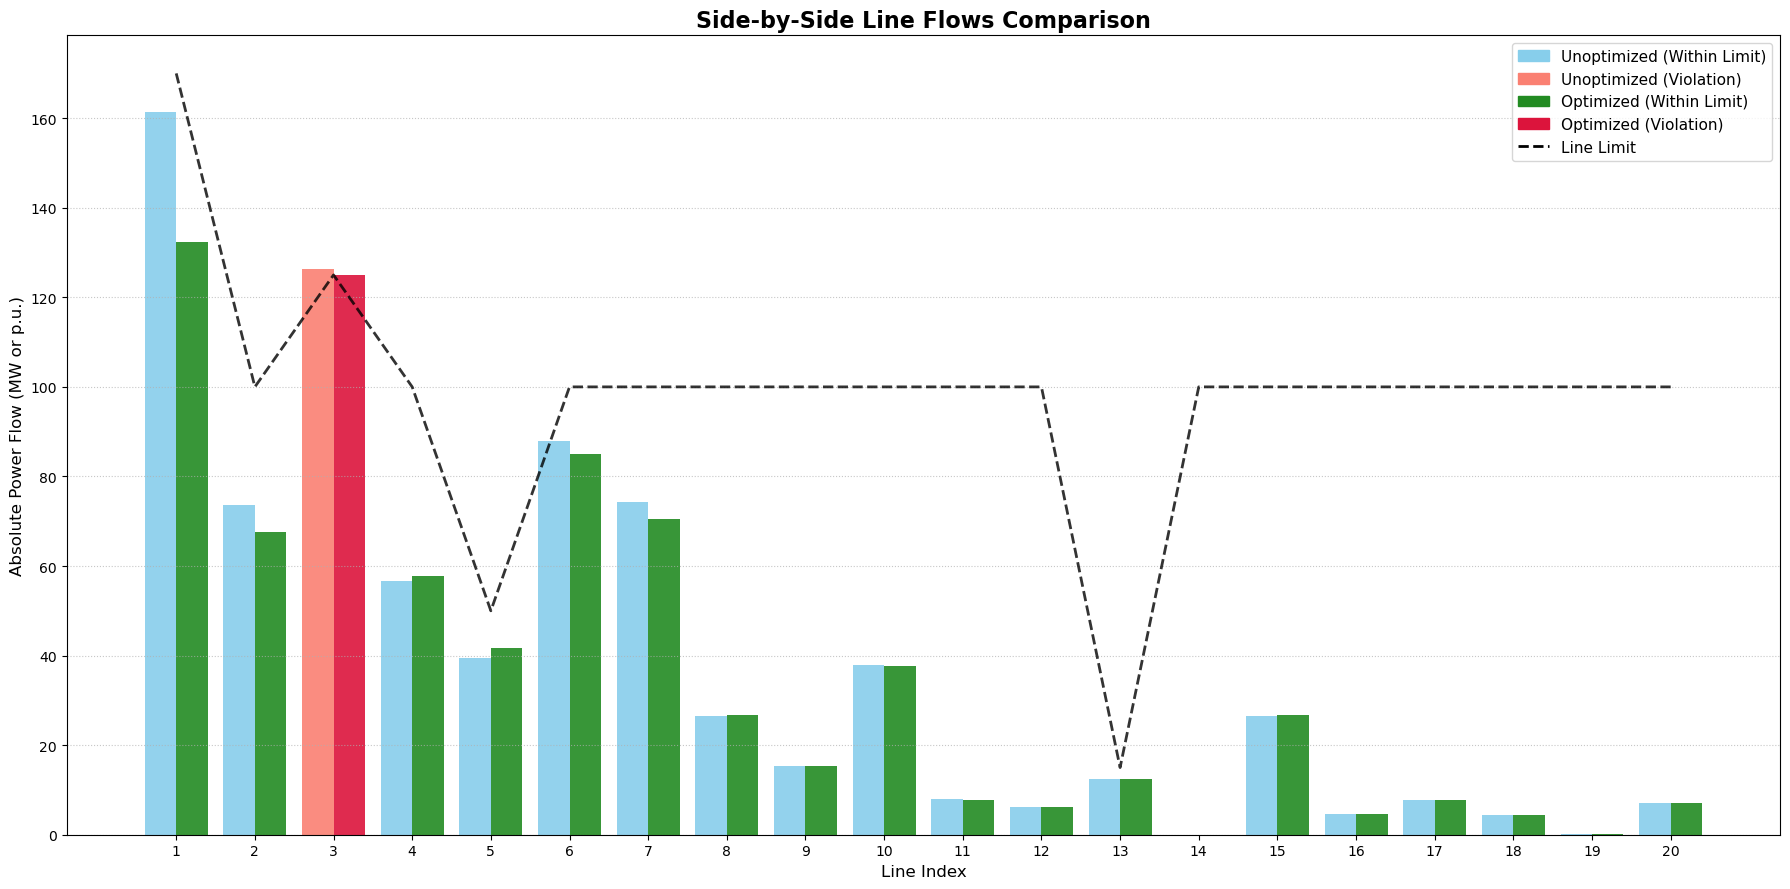

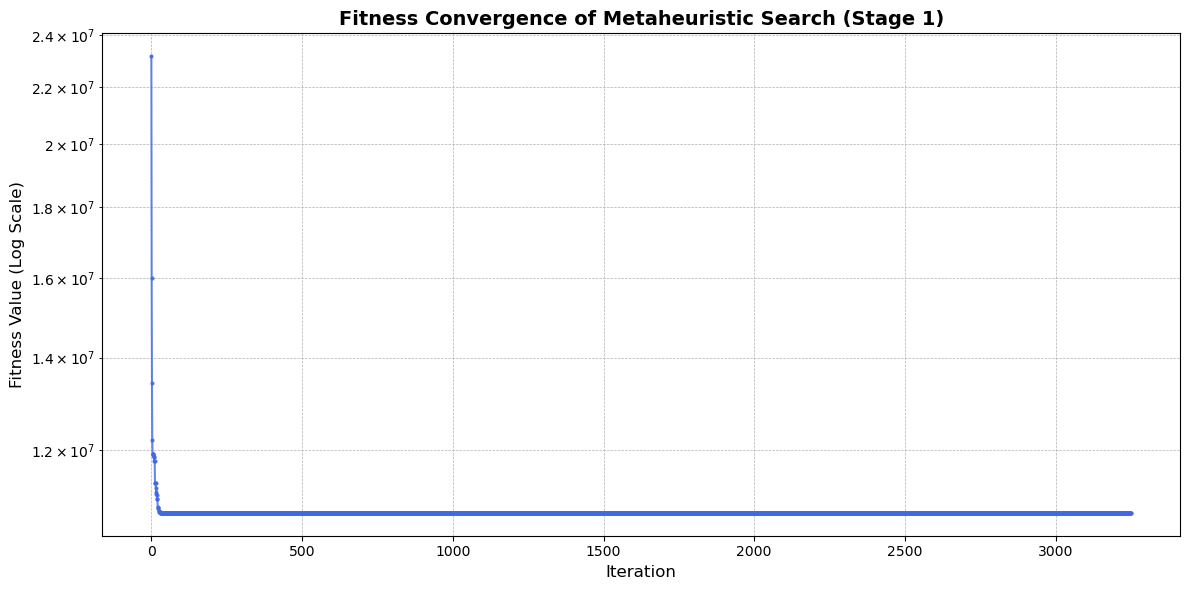


--- Load Shed Summary ---
Total Load Shed: 4.2185 MW (or p.u.)


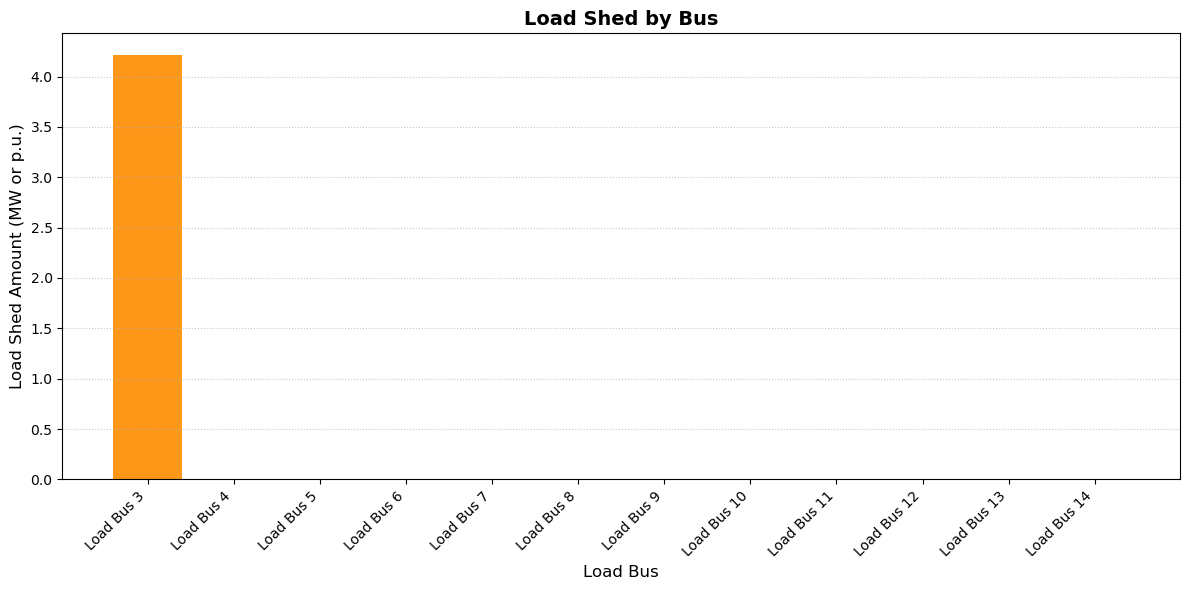


--- Generating 3D Interactive Topological Fitness Map ---
Visualizing landscape by varying Generator 1 (X-axis) and Generator 2 (Y-axis)

An unexpected error occurred during the run: Invalid property specified for object of type plotly.graph_objs.Contour: 'project'

Did you mean "text"?

    Valid properties:
        autocolorscale
            Determines whether the colorscale is a default palette
            (`autocolorscale: true`) or the palette determined by
            `colorscale`. In case `colorscale` is unspecified or
            `autocolorscale` is true, the default palette will be
            chosen according to whether numbers in the `color`
            array are all positive, all negative or mixed.
        autocontour
            Determines whether or not the contour level attributes
            are picked by an algorithm. If True, the number of
            contour levels can be set in `ncontours`. If False, set
            the contour level attributes in `contours`.
     


Run another scenario? (y/n): n



Script finished.


In [139]:
# --- CELL 5: MAIN EXECUTION BLOCK ---
# This is the main driver of the script. It handles user input,
# runs the optimization, and calls the visualization and reporting functions.

if __name__ == "__main__":
    # Check if definitions from other cells exist. This is crucial when running
    # as a script or to ensure notebook cells have been executed in order.
    if 'HybridPowerFlowOptimizer' not in globals() or \
       'optimize_power_flow_hybrid_polish' not in globals() or \
       'visualize_detailed_results' not in globals() or \
       'visualize_topological_map_3d' not in globals() or \
       'save_results_to_file' not in globals():
        print("ERROR: One or more definition cells were not run. Please ensure all code is executed.")
        sys.exit()

    matrix_file_name = 'lock.csv'
    try:
        print(f"Loading system matrix A from: {matrix_file_name}")
        A = pd.read_csv(matrix_file_name, header=None).to_numpy()
        num_lines_main, num_buses_main = A.shape
        print(f"System dimensions: {num_lines_main} lines, {num_buses_main} buses.")
    except Exception as e:
        print(f"FATAL ERROR loading '{matrix_file_name}': {e}. Exiting.")
        sys.exit()

    while True:
        print("\n" + "="*25 + " New Scenario (Hybrid Polish) " + "="*25)
        print("Objective: 1. Meet Limits, Minimize Load Shed & Generator Deviation")
        
        try:
            # --- User Input: Line Limits ---
            print(f"\n>>> Enter LINE power limits for {num_lines_main} lines (e.g., space-separated values):")
            while True:
                try:
                    limits_str = input("  Line limits: ")
                    line_limits_list = [float(x) for x in limits_str.split()]
                    if len(line_limits_list) == num_lines_main:
                        line_limits_input = np.abs(np.array(line_limits_list))
                        break
                    else:
                        print(f"  Error: Expected {num_lines_main} values, but got {len(line_limits_list)}. Please re-enter.")
                except ValueError:
                    print("  Error: Invalid number format. Please enter space-separated numbers.")

            # --- User Input: Initial Bus Injections (B) ---
            print(f"\n>>> Enter INITIAL power injections (B) for ALL {num_buses_main} buses:")
            print("    (Positive for Generators, Negative for Loads, e.g., space-separated)")
            while True:
                try:
                    b_str = input("  Initial injections (B): ")
                    B_input_list = [float(x) for x in b_str.split()]
                    if len(B_input_list) == num_buses_main:
                        B_input = np.array(B_input_list).reshape(-1, 1)
                        break
                    else:
                        print(f"  Error: Expected {num_buses_main} values, got {len(B_input_list)}. Please re-enter.")
                except ValueError:
                    print("  Error: Invalid number format. Please enter space-separated numbers.")

            # Identify generator buses to guide the next inputs
            temp_gen_indices = np.where(B_input.flatten() > 1e-6)[0]
            if len(temp_gen_indices) == 0:
                print("\nERROR: No Generators identified in your B input! Cannot proceed.")
                continue

            print(f"-> Based on input, identified Generator buses: {temp_gen_indices+1}")

            # --- User Input: Generator-Specific Data ---
            gen_costs_input = np.zeros(num_buses_main)
            gen_limits_min_input = np.zeros(num_buses_main)
            gen_limits_max_input = np.zeros(num_buses_main)
            print(f"\n>>> Enter GENERATOR specific data for buses: {temp_gen_indices+1}:")

            print("  Enter Generator Cost Coefficients ($/MW of deviation):")
            for i in temp_gen_indices:
                while True:
                    try:
                        cost_str = input(f"    G{i+1} cost: ")
                        gen_costs_input[i] = float(cost_str)
                        break
                    except ValueError: print("    Invalid number. Please re-enter.")

            print("  Enter Generator MINIMUM Output Limit (MW):")
            for i in temp_gen_indices:
                while True:
                    try:
                        min_str = input(f"    G{i+1} min limit: ")
                        gen_limits_min_input[i] = float(min_str)
                        break
                    except ValueError: print("    Invalid number. Please re-enter.")

            print("  Enter Generator MAXIMUM Output Limit (MW):")
            for i in temp_gen_indices:
                while True:
                    try:
                        max_str = input(f"    G{i+1} max limit: ")
                        max_val = float(max_str)
                        if max_val < gen_limits_min_input[i]:
                            print(f"    Error: Max limit ({max_val}) cannot be less than Min limit ({gen_limits_min_input[i]}). Re-enter.")
                            continue
                        gen_limits_max_input[i] = max_val
                        break
                    except ValueError: print("    Invalid number. Please re-enter.")

        except (EOFError, KeyboardInterrupt):
            print("\n\nInput process interrupted. Exiting script.")
            break

        # --- Run Optimization ---
        try:
            # Create an optimizer instance to be used by visualization functions
            vis_optimizer = HybridPowerFlowOptimizer(A, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input, B_input)

            # Run the full hybrid polish optimization
            B_polished, fit_hist, C_polished, C_unoptimized, final_feasible, details = optimize_power_flow_hybrid_polish(
                A, B_input, line_limits_input, gen_costs_input, gen_limits_min_input, gen_limits_max_input,
                iterations=3250, population_size=100
            )

            # --- Visualize Results ---
            visualize_detailed_results(
                B_input, B_polished, C_unoptimized, C_polished, 
                line_limits_input, fit_hist, details
            )
            visualize_topological_map_3d(vis_optimizer, B_polished)
            
            # --- Save Final Report ---
            if final_feasible:
                save_results_to_file(
                    B_input, B_polished, C_unoptimized, C_polished,
                    line_limits_input, details, final_feasible
                )
            else:
                print("\nFinal solution was not feasible. Report not saved.")

        except Exception as e:
            print(f"\nAn unexpected error occurred during the run: {e}")
        
        try:
            run_again = input("\nRun another scenario? (y/n):").strip().lower()
            if run_again != 'y':
                break
        except (EOFError, KeyboardInterrupt):
            break
            
    print("\nScript finished.")


In [ ]:
170 100 125 100 50 100 100 100 100 100 100 100 15 100 100 100 100 100 100 100

In [ ]:
235 61.3 -214.2 -1.4 -1 -11.2 0 0 -29.50 -9 -3.5 -6.1 -5.5 -14.9